# Compare MPN vs RNN performance on the same figure

Overlay the accuracy curves from a `train_mpn.py` run and a `train_rnn.py` run
(both saved as `.npz` under `figure_data/`) on a single train/test figure, so
the two model families' learning rules can be compared directly.

Just set the two `.npz` file names in the config cell below (with or without the
`.npz` extension, stem or full path — both are resolved against `figure_data/`).
The **task name**, **hidden size**, and **output-training mode** (`exact_readout`
etc.) are all read from the file names; the hidden size and output-training mode
**must agree** between the two runs (else the comparison isn't apples-to-apples,
so the notebook stops), and all three are shown in the figure title.

**Convention:** MPN rules are drawn as **solid** lines, RNN rules as **dashed**;
color still encodes the learning rule (BPTT blue, diagonal RFLO red, direct
purple), reusing the same `RULE_COLOR` / `RULE_LABEL` maps as the train scripts.

In [1]:
import pathlib
import re

import numpy as np
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ../core + ../scripts to sys.path; exposes ROOT
import train_mpn as tm   # RULE_LABEL / RULE_COLOR for the MPN rules
import train_rnn as tr   # RULE_LABEL / RULE_COLOR for the RNN rules

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

FIG_DATA_DIR = _bootstrap.ROOT / "figure_data"   # where the .npz files live
FIG_OUT_DIR = _bootstrap.ROOT / "figure"          # where the combined figure is saved

## 1. Choose the two runs to overlay

Set the MPN and RNN `.npz` names. These are the files `train_mpn.py` /
`train_rnn.py` write to `figure_data/` (same stem as their `.png`). The
extension is optional; a bare stem is resolved against `figure_data/`.

In [2]:
# --- run selection: fill in your two file names (stem, name.npz, or full path) ---
MPN_FILE = "train_dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_eta1.00_lam0.99_runs3"
RNN_FILE = "train_rnn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_runs3"


def resolve_npz(name):
    """Resolve a user-supplied name to an existing .npz path. Accepts a bare stem,
    a 'name.npz', or an absolute/relative path; bare names look in figure_data/."""
    name = str(name)
    if not name.endswith(".npz"):
        name += ".npz"
    p = pathlib.Path(name)
    if not p.is_absolute() and not p.exists():
        p = FIG_DATA_DIR / p.name
    if not p.exists():
        raise FileNotFoundError(f"npz not found: {p}")
    return p


MPN_PATH = resolve_npz(MPN_FILE)
RNN_PATH = resolve_npz(RNN_FILE)
print(f"MPN <- {MPN_PATH}")
print(f"RNN <- {RNN_PATH}")

MPN <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure_data/train_dmpn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_eta1.00_lam0.99_runs3.npz
RNN <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure_data/train_rnn_contextdelaydm1_h200_b128_n5000_lr1e-03_exact_readout_runs3.npz


## 2. Load the curves; extract & cross-check the run descriptors

Each `.npz` (written by `train_common.save_plot_data`) stores the x-axis
(`record_steps`), the list of `rules`, and per-rule `mean__<rule>__<split>` /
`std__<rule>__<split>` arrays for `split` in `{train, valid}`.

The **task name**, **hidden size**, and **output-training mode** are parsed
straight out of the file names (`train_<net>_<task>_h<hidden>_..._<readout>_...`).
The hidden size and output-training mode **must match** between the two runs —
otherwise the overlay compares networks trained under different conditions, so we
raise. (The task is also cross-checked; a mismatch warns but still plots.)

In [3]:
def load_curves(path):
    """Return (record_steps, rules, agg, meta) from a train_common .npz.
    agg[rule][split] = {'mean': array, 'std': array}; meta holds the scalars."""
    d = np.load(path, allow_pickle=True)
    rules = [str(r) for r in d["rules"]]
    steps = np.asarray(d["record_steps"])
    agg = {r: {sp: {"mean": np.asarray(d[f"mean__{r}__{sp}"]),
                    "std": np.asarray(d[f"std__{r}__{sp}"])}
               for sp in ("train", "valid")}
           for r in rules}
    scalar = lambda k: (d[k].item() if k in d.files and d[k].shape == () else None)
    meta = {k: scalar(k) for k in ("ruleset", "n_hidden", "n_runs", "batch",
                                   "lr", "feedback_mode", "title")}
    return steps, rules, agg, meta


def parse_descriptors(name):
    """Pull (task, hidden, readout) out of a train_{dmpn,mpn1,rnn}_... file name.
    hidden is the '_h<N>_' field (int); readout is the output-training / feedback
    mode ('exact_readout' or 'random_fixed'); task is everything between the net
    tag and '_h<N>'."""
    stem = pathlib.Path(str(name)).name
    task = re.search(r"train_(?:dmpn|mpn1|rnn)_(.+?)_h\d+", stem)
    hidden = re.search(r"_h(\d+)_", stem)
    readout = re.search(r"_(exact_readout|random_fixed)_", stem)
    return (task.group(1) if task else None,
            int(hidden.group(1)) if hidden else None,
            readout.group(1) if readout else None)


mpn_steps, mpn_rules, mpn_agg, mpn_meta = load_curves(MPN_PATH)
rnn_steps, rnn_rules, rnn_agg, rnn_meta = load_curves(RNN_PATH)

mpn_task, mpn_hidden, mpn_readout = parse_descriptors(MPN_PATH)
rnn_task, rnn_hidden, rnn_readout = parse_descriptors(RNN_PATH)

# Hidden size and output-training mode MUST agree for a fair comparison.
for label, mval, rval in [("hidden size", mpn_hidden, rnn_hidden),
                          ("output-training mode", mpn_readout, rnn_readout)]:
    if mval is None or rval is None:
        raise ValueError(f"could not parse {label} from a file name "
                         f"(MPN={mval!r}, RNN={rval!r}).")
    if mval != rval:
        raise ValueError(f"{label} differs between the two runs: "
                         f"MPN={mval!r} vs RNN={rval!r}. The combined figure "
                         "requires them to match.")

# Task is cross-checked too, but only warns (you may deliberately overlay tasks).
if mpn_task != rnn_task:
    print(f"WARNING: task differs between files (MPN={mpn_task!r}, RNN={rnn_task!r}) "
          "- overlaying anyway.")

TASK, HIDDEN, READOUT = mpn_task, mpn_hidden, mpn_readout
print(f"task = {TASK}   hidden = {HIDDEN}   output training = {READOUT}")
print(f"MPN rules: {mpn_rules}  ->  {[tm.RULE_LABEL.get(r, r) for r in mpn_rules]}")
print(f"RNN rules: {rnn_rules}  ->  {[tr.RULE_LABEL.get(r, r) for r in rnn_rules]}")
print(f"n_runs: MPN={mpn_meta['n_runs']}  RNN={rnn_meta['n_runs']}")

task = contextdelaydm1   hidden = 200   output training = exact_readout
MPN rules: ['bptt', 'local_diag_rflo', 'local_direct']  ->  ['BPTT', 'diagonal RFLO', 'direct']
RNN rules: ['bptt', 'local_diag_rflo']  ->  ['BPTT', 'RFLO']
n_runs: MPN=3  RNN=3


## 3. Overlay MPN and RNN on one figure

Two panels (train / test) like the per-model figures, but with **both** models on
each: MPN solid, RNN dashed, color per learning rule (mean line + ± std band).
The legend is tagged `MODEL: rule` so every curve is unambiguous, and the title
records the (shared) task, hidden size, and output-training mode.

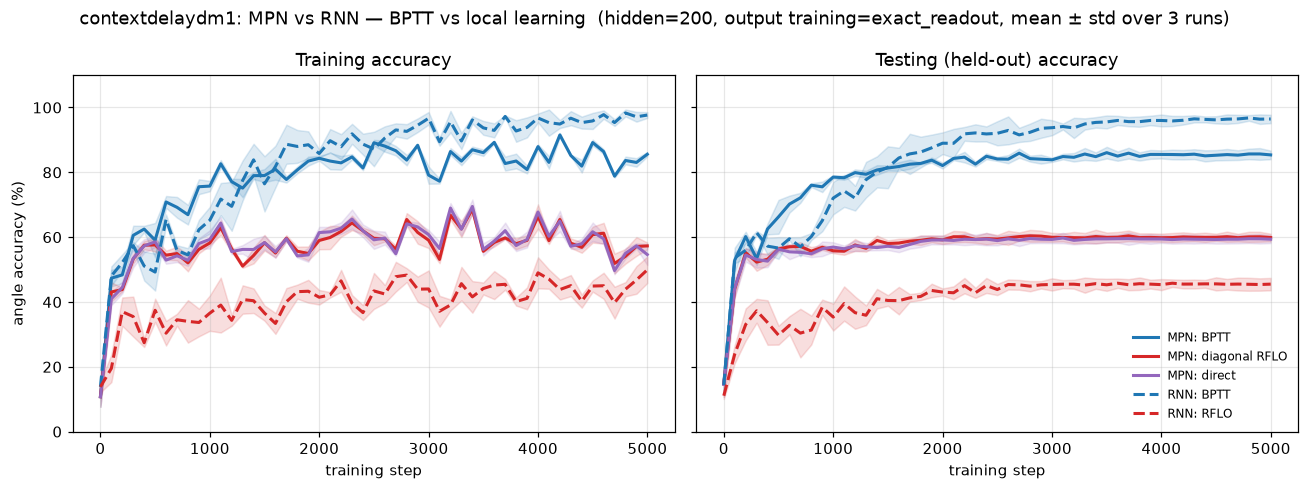

In [4]:
# Per-model style: solid MPN, dashed RNN; reuse each script's rule color/label maps.
SOURCES = [
    dict(model="MPN", linestyle="-", steps=mpn_steps, rules=mpn_rules, agg=mpn_agg,
         color=tm.RULE_COLOR, label=tm.RULE_LABEL, meta=mpn_meta),
    dict(model="RNN", linestyle="--", steps=rnn_steps, rules=rnn_rules, agg=rnn_agg,
         color=tr.RULE_COLOR, label=tr.RULE_LABEL, meta=rnn_meta),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, split, title in zip(axes, ("train", "valid"),
                            ("Training accuracy", "Testing (held-out) accuracy")):
    for src in SOURCES:
        for rule in src["rules"]:
            # Accuracy stored as a fraction in [0, 1]; plot as percent.
            mean = 100.0 * np.asarray(src["agg"][rule][split]["mean"])
            std = 100.0 * np.asarray(src["agg"][rule][split]["std"])
            color = src["color"].get(rule, None)
            lbl = f"{src['model']}: {src['label'].get(rule, rule)}"
            ax.plot(src["steps"], mean, color=color, ls=src["linestyle"], lw=2, label=lbl)
            ax.fill_between(src["steps"], mean - std, mean + std, color=color, alpha=0.15)
    ax.set_title(title)
    ax.set_xlabel("training step")
    ax.grid(alpha=0.3)
    ax.set_ylim(0, 110)
axes[0].set_ylabel("angle accuracy (%)")
axes[1].legend(loc="lower right", frameon=False, fontsize=8)

n_runs = mpn_meta["n_runs"] if mpn_meta["n_runs"] == rnn_meta["n_runs"] else \
    f"{mpn_meta['n_runs']}/{rnn_meta['n_runs']}"
fig.suptitle(f"{TASK}: MPN vs RNN — BPTT vs local learning  "
             f"(hidden={HIDDEN}, output training={READOUT}, "
             f"mean ± std over {n_runs} runs)")
fig.tight_layout()
plt.show()

## 4. Save the combined figure

Writes to `figure/compare_mpn_rnn_<task>_h<hidden>_<readout>.png` alongside the
per-model figures — the descriptors are in the name so different configs don't
overwrite each other.

In [5]:
FIG_OUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = FIG_OUT_DIR / f"compare_mpn_rnn_{TASK}_h{HIDDEN}_{READOUT}.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure: {out_path}")

Saved figure: /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/figure/compare_mpn_rnn_contextdelaydm1_h200_exact_readout.png
